In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [3]:
df = pd.read_csv('/content/drive/My Drive/uk_data_clean.csv')

In [4]:
pivoted = df.pivot(index='datetime', columns='id', values='target')

def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))

pivoted.index = pivoted.index.map(dtarg)

np.random.seed(216)

testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]

energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

In [6]:
energy_testing_set.columns

Index(['uk_MAC003375', 'uk_MAC004019', 'uk_MAC003901', 'uk_MAC002320',
       'uk_MAC002547', 'uk_MAC001857', 'uk_MAC003796', 'uk_MAC003081',
       'uk_MAC000714', 'uk_MAC003958',
       ...
       'uk_MAC000742', 'uk_MAC002753', 'uk_MAC003397', 'uk_MAC001665',
       'uk_MAC004449', 'uk_MAC003082', 'uk_MAC005341', 'uk_MAC005162',
       'uk_MAC001869', 'uk_MAC000769'],
      dtype='object', name='id', length=183)

In [8]:
energy.columns

Index(['uk_MAC000010', 'uk_MAC000018', 'uk_MAC000019', 'uk_MAC000027',
       'uk_MAC000034', 'uk_MAC000048', 'uk_MAC000049', 'uk_MAC000057',
       'uk_MAC000075', 'uk_MAC000091',
       ...
       'uk_MAC005475', 'uk_MAC005480', 'uk_MAC005508', 'uk_MAC005525',
       'uk_MAC005526', 'uk_MAC005527', 'uk_MAC005539', 'uk_MAC005540',
       'uk_MAC005545', 'uk_MAC005549'],
      dtype='object', name='id', length=736)

In [9]:
pivot = energy.copy()

In [11]:
pivot = pivot.iloc[:,:5]

In [12]:
pivot

id,uk_MAC000010,uk_MAC000018,uk_MAC000019,uk_MAC000027,uk_MAC000034
datetime,,,,,
2012-11-01 00:00:00,0.863,0.335,0.043,0.177,0.584
2012-11-01 00:30:00,0.287,0.500,0.069,0.185,0.609
2012-11-01 01:00:00,0.231,0.675,0.092,0.157,0.164
2012-11-01 01:30:00,0.177,0.554,0.088,0.179,0.102
2012-11-01 02:00:00,0.231,0.556,0.095,0.104,0.129
...,...,...,...,...,...
2013-11-30 21:30:00,1.059,0.148,0.216,0.302,0.296
2013-11-30 22:00:00,0.833,0.139,0.192,0.258,0.264
2013-11-30 22:30:00,0.439,0.140,0.203,0.258,0.244


In [13]:
# Time features
tf = pd.DataFrame(index=pivot.index)
tf['hour'] = pivot.index.hour + pivot.index.minute / 60
tf['dow'] = pivot.index.dayofweek
tf['month'] = pivot.index.month

# Cyclical encoding, this way model understands how close 23:30 and 00:30 are...., we could possible have remove month versions.
import numpy as np
tf['hour_sin'] = np.sin(2 * np.pi * tf['hour'] / 24)
tf['hour_cos'] = np.cos(2 * np.pi * tf['hour'] / 24)
tf['dow_sin'] = np.sin(2 * np.pi * tf['dow'] / 7)
tf['dow_cos'] = np.cos(2 * np.pi * tf['dow'] / 7)
tf['month_sin'] = np.sin(2 * np.pi * tf['month'] / 12)
tf['month_cos'] = np.cos(2 * np.pi * tf['month'] / 12)

time_features = tf[['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']].values

In [15]:
pivot.shape[0]

18960

In [16]:
input_window = 7 * 48       # 336
forecast_horizon = 1 * 48   # 48

total_samples = pivot.shape[0] - input_window - forecast_horizon

# Create raw data splits before scaling
split1 = int(0.7 * total_samples)
split2 = int(0.85 * total_samples)

train_end = split1 + input_window + forecast_horizon
val_end = split2 + input_window + forecast_horizon

# Raw splits, unscaled
pivot_np = pivot.values
train_raw = pivot_np[:train_end]
val_raw   = pivot_np[train_end:val_end]
test_raw  = pivot_np[val_end:]

In [17]:
train_raw.shape

(13387, 5)

In [18]:
val_raw.shape

(2786, 5)

In [19]:
test_raw.shape

(2787, 5)

In [20]:
# Fit scaler on training data
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

# Time features must also be split accordingly
tf_train = time_features[:train_end]
tf_val   = time_features[train_end:val_end]
tf_test  = time_features[val_end:]

In [21]:
# Sequence creation function
def create_sequences(data, time_feats, input_window, forecast_horizon):
    X, y = [], []
    num_households = data.shape[1]
    for c in range(num_households):
        series = data[:, c]
        for i in range(len(series) - input_window - forecast_horizon):
            hist = series[i:i+input_window]
            tf_hist = time_feats[i:i+input_window, :]
            X.append(np.hstack([hist.reshape(-1, 1), tf_hist]))
            y.append(series[i+input_window:i+input_window+forecast_horizon].reshape(-1, 1))
    return np.array(X), np.array(y)

# Build sequences for each set
X_train, y_train = create_sequences(train_scaled, tf_train, input_window, forecast_horizon)
X_val, y_val     = create_sequences(val_scaled, tf_val, input_window, forecast_horizon)
X_test, y_test   = create_sequences(test_scaled, tf_test, input_window, forecast_horizon)

print("X_train shape:", X_train.shape)  # (samples, 336, 7)
print("y_train shape:", y_train.shape)  # (samples, 48, 1)

X_train shape: (65015, 336, 7)
y_train shape: (65015, 48, 1)


In [22]:
print("X_val shape:", X_val.shape)  # (samples, 336, 7)
print("y_val shape:", y_val.shape)  # (samples, 48, 1)
print("X_test shape:", X_test.shape)  # (samples, 336, 7)
print("y_test shape:", y_test.shape)  # (samples, 48, 1)

X_val shape: (12010, 336, 7)
y_val shape: (12010, 48, 1)
X_test shape: (12015, 336, 7)
y_test shape: (12015, 48, 1)


In [23]:
# LSTM model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense

model = Sequential([
    LSTM(64, input_shape=(input_window, X_train.shape[2])),
    RepeatVector(forecast_horizon),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 48, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 48, 1)          │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=2,
    batch_size=8,
    verbose=1
)

Epoch 1/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 772s 94ms/step - loss: 0.0101 - val_loss: 0.0042
Epoch 2/2
8127/8127 ━━━━━━━━━━━━━━━━━━━━ 813s 96ms/step - loss: 0.0067 - val_loss: 0.0041


In [25]:
model.save('/content/drive/My Drive/random5_lstm_energy_model.h5')


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on scaled data
y_pred_scaled = model.predict(X_test)

# Setup
num_households = pivot.shape[1]  # 5 households
samples_per_household = len(X_test) // num_households

# Store all true/pred values unscaled
y_true_unscaled_all = []
y_pred_unscaled_all = []

for h in range(num_households):
    # Slice predictions and true labels for this household
    start = h * samples_per_household
    end = (h + 1) * samples_per_household

    y_pred_scaled_h = y_pred_scaled[start:end].reshape(-1, 1)  # (samples * 48, 1)
    y_true_scaled_h = y_test[start:end].reshape(-1, 1)

    # Get column-wise scaler params
    data_min = scaler.data_min_[h]
    data_max = scaler.data_max_[h]

    # Inverse scale
    y_pred_unscaled_h = y_pred_scaled_h * (data_max - data_min) + data_min
    y_true_unscaled_h = y_true_scaled_h * (data_max - data_min) + data_min

    y_pred_unscaled_all.append(y_pred_unscaled_h.flatten())
    y_true_unscaled_all.append(y_true_unscaled_h.flatten())

# Combine all households
y_pred_unscaled_flat = np.concatenate(y_pred_unscaled_all)
y_true_unscaled_flat = np.concatenate(y_true_unscaled_all)

# Accuracy metrics
mae_unscaled = mean_absolute_error(y_true_unscaled_flat, y_pred_unscaled_flat)
mse_unscaled = mean_squared_error(y_true_unscaled_flat, y_pred_unscaled_flat)
rmse_unscaled = np.sqrt(mean_squared_error(y_true_unscaled_flat, y_pred_unscaled_flat))

print(f"MAE (Unscaled):  {mae_unscaled:.4f}")
print(f"MSE (Unscaled): {mse_unscaled:.4f}")
print(f"RMSE (Unscaled): {rmse_unscaled:.4f}")


376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step
MAE (Unscaled):  0.1287
MSE (Unscaled): 0.0458
RMSE (Unscaled): 0.2141


In [43]:
# to inspect which household performs better/worse

for h in range(num_households):
    mae_h = mean_absolute_error(y_true_unscaled_all[h], y_pred_unscaled_all[h])
    mse_h = mean_squared_error(y_true_unscaled_all[h], y_pred_unscaled_all[h])
    rmse_h = np.sqrt(mean_squared_error(y_true_unscaled_all[h], y_pred_unscaled_all[h]))
    print(f"Household {h+1}: MAE = {mae_h:.4f}, MSE = {mse_h:.4f}, RMSE = {rmse_h:.4f}")


Household 1: MAE = 0.2218, MSE = 0.1019, RMSE = 0.3192
Household 2: MAE = 0.1157, MSE = 0.0274, RMSE = 0.1654
Household 3: MAE = 0.0482, MSE = 0.0080, RMSE = 0.0893
Household 4: MAE = 0.0758, MSE = 0.0120, RMSE = 0.1095
Household 5: MAE = 0.1820, MSE = 0.0799, RMSE = 0.2827


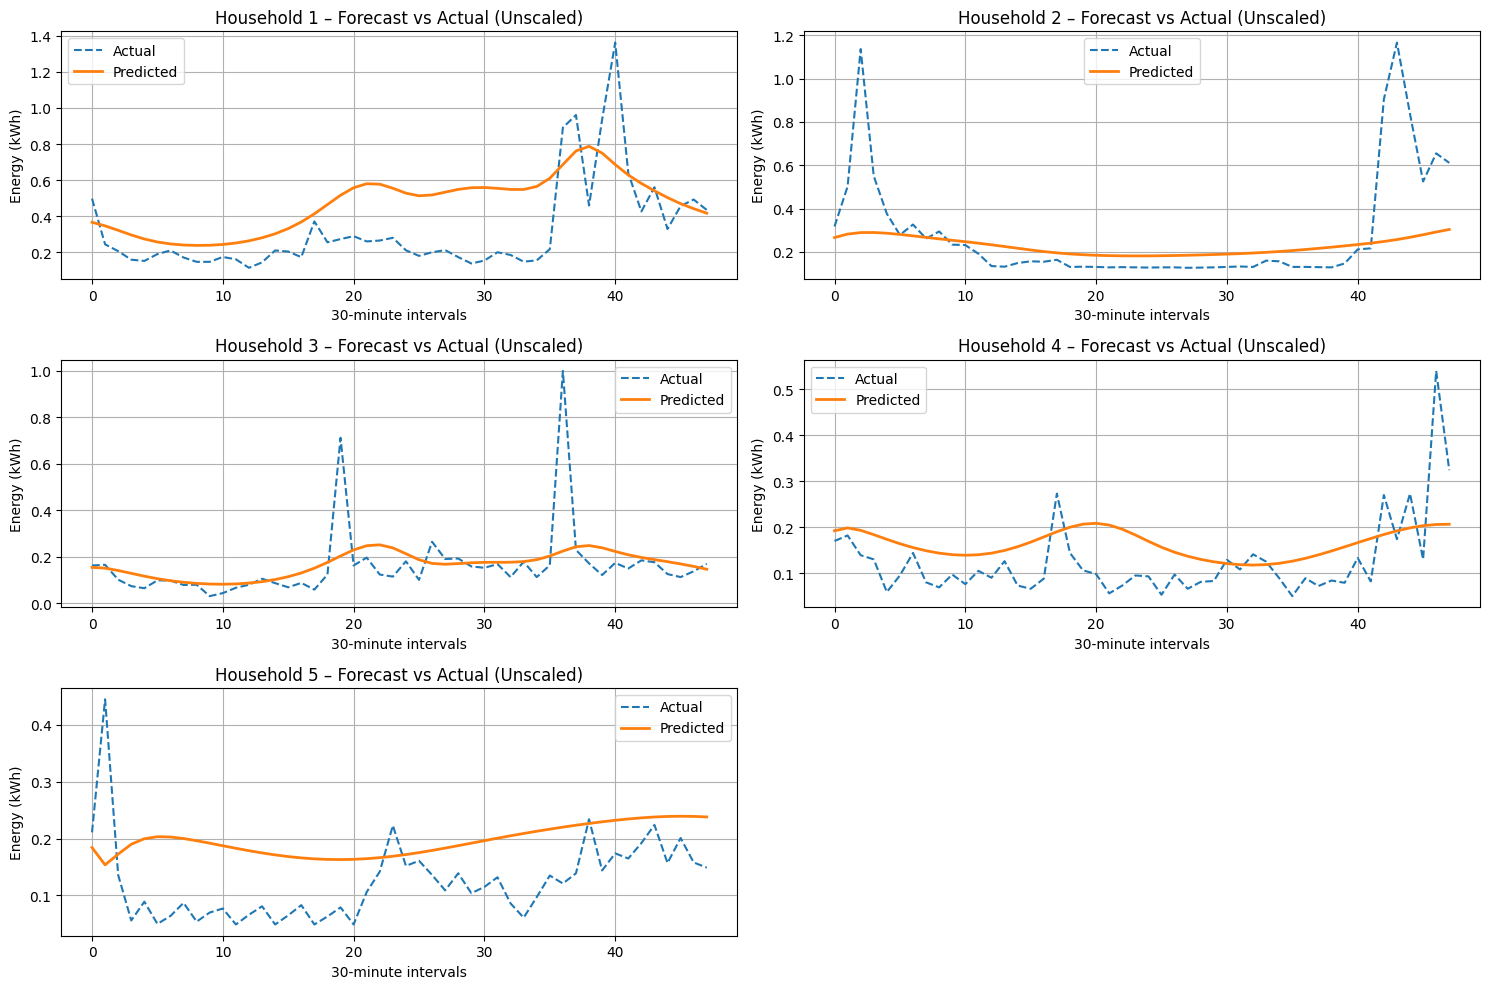

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

for h in range(num_households):
    idx = h * samples_per_household  # first test sample for this household
    y_pred_h = y_pred_unscaled_all[h].reshape(-1, 48)  # reshape back to (samples, 48)
    y_true_h = y_true_unscaled_all[h].reshape(-1, 48)

    y_pred_plot = y_pred_h[0]  # first forecasted day
    y_true_plot = y_true_h[0]

    plt.subplot(3, 2, h + 1)
    plt.plot(y_true_plot, linestyle='--', label='Actual')
    plt.plot(y_pred_plot, linewidth=2, label='Predicted')
    plt.title(f'Household {h+1} – Forecast vs Actual (Unscaled)')
    plt.xlabel("30-minute intervals")
    plt.ylabel("Energy (kWh)")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


In [44]:
# Testing on UNSEEN households (183 that we separated in the beginning)

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Data: unseen households (183)
unseen_households = energy_testing_set.columns
num_unseen = len(unseen_households)

mae_list = []
mse_list = []
rmse_list = []
house_ids = []

for i, col in enumerate(unseen_households):
    series = energy_testing_set[col].values.reshape(-1, 1)

    # Skip short/incomplete series (shouldn't happen in our data)
    if len(series) < (input_window + forecast_horizon):
        continue

    # Scale this household independently
    scaler_h = MinMaxScaler()
    series_scaled = scaler_h.fit_transform(series)

    # Create time features (already built earlier)
    tf_unseen = time_features

    # Create sequences for this household
    X_h, y_h = create_sequences(series_scaled, tf_unseen, input_window, forecast_horizon)

    # Skip if not enough sequences
    if X_h.shape[0] == 0:
        continue

    # Predict
    y_h_pred = model.predict(X_h)

    # Inverse transform
    y_h_pred_unscaled = scaler_h.inverse_transform(y_h_pred.reshape(-1, 1)).flatten()
    y_h_true_unscaled = scaler_h.inverse_transform(y_h.reshape(-1, 1)).flatten()

    # Compute metrics
    mae = mean_absolute_error(y_h_true_unscaled, y_h_pred_unscaled)
    mse= mean_squared_error(y_h_true_unscaled, y_h_pred_unscaled)
    rmse = np.sqrt(mean_squared_error(y_h_true_unscaled, y_h_pred_unscaled))

    # Save results
    mae_list.append(mae)
    mse_list.append(mse)
    rmse_list.append(rmse)
    house_ids.append(col)

    print(f"Household {i+1}/{num_unseen} ({col}): MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}")

581/581 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step
Household 1/183 (uk_MAC003375): MAE = 0.0906, MSE = 0.0176, RMSE = 0.1329
581/581 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step
Household 2/183 (uk_MAC004019): MAE = 0.1143, MSE = 0.0267, RMSE = 0.1635
581/581 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step
Household 3/183 (uk_MAC003901): MAE = 0.1012, MSE = 0.0221, RMSE = 0.1488
581/581 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step
Household 4/183 (uk_MAC002320): MAE = 0.1182, MSE = 0.0321, RMSE = 0.1792
581/581 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step
Household 5/183 (uk_MAC002547): MAE = 0.0972, MSE = 0.0194, RMSE = 0.1392
581/581 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step
Household 6/183 (uk_MAC001857): MAE = 0.1144, MSE = 0.0285, RMSE = 0.1689
581/581 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step
Household 7/183 (uk_MAC003796): MAE = 0.1688, MSE = 0.0719, RMSE = 0.2681
581/581 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step
Household 8/183 (uk_MAC003081): MAE = 0.1141, MSE = 0.0317, RMSE = 0.1782
581/581 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step
Household 9/183 (uk_M

In [45]:
# Overall metrics
print("\n Summary over all unseen households:")
print(f"Average MAE: {np.mean(mae_list):.4f}")
print(f"Average MSE: {np.mean(mse_list):.4f}")
print(f"Average RMSE: {np.mean(rmse_list):.4f}")


 Summary over all unseen households:
Average MAE: 0.1340
Average MSE: 0.0687
Average RMSE: 0.2130


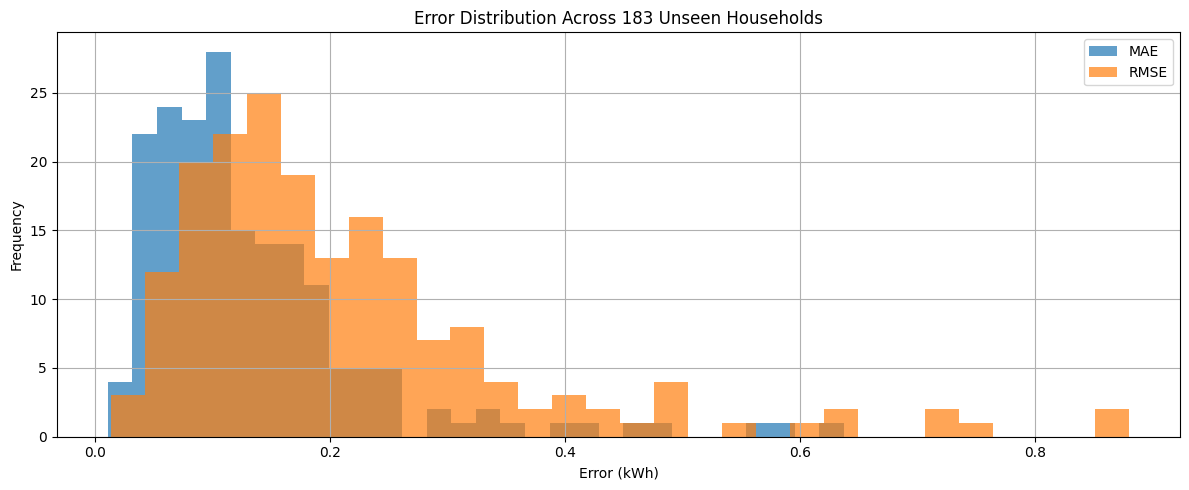

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(mae_list, bins=30, alpha=0.7, label='MAE')
plt.hist(rmse_list, bins=30, alpha=0.7, label='RMSE')
plt.title("Error Distribution Across 183 Unseen Households")
plt.xlabel("Error (kWh)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
results_df = pd.DataFrame({
    'household_id': house_ids,
    'mae': mae_list,
    'mse': mse_list,
    'rmse': rmse_list
})
results_df.to_csv('/content/drive/My Drive/unseen_household_accuracy.csv', index=False)


In [48]:
results_df

,household_id,mae,mse,rmse
0,uk_MAC003375,0.090565,0.017650,0.132852
1,uk_MAC004019,0.114273,0.026747,0.163545
2,uk_MAC003901,0.101170,0.022131,0.148767
3,uk_MAC002320,0.118219,0.032099,0.179161
4,uk_MAC002547,0.097233,0.019378,0.139207
...,...,...,...,...
178,uk_MAC003082,0.050688,0.005466,0.073932
179,uk_MAC005341,0.471495,0.569632,0.754740
180,uk_MAC005162,0.146513,0.073116,0.270399
181,uk_MAC001869,0.143261,0.047446,0.217820
